In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  


In [2]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = (catalog.open_dataset(id=catalog.Items[1].id)).isel(t = 0, drop = True)
config = config.rename({'z': 'nav_lev'})

datasets = {"parent": {"domain": config, "gridT": ds1}}
dt = NEMODataTree.from_datasets(datasets = datasets)

weighted_mean = dt.masked_statistic(grid='/gridT', var='tos_con', lon_poly = [-20.0, -5.0, -5.0, -20.0, -20.0], lat_poly = [45.0, 45.0, 55.0, 55.0, 45], statistic="weighted_mean", dims=["i", "j"])





            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [7]:
august_means = (weighted_mean.where(weighted_mean['time_counter'].dt.month == 8, drop=True)).compute()
august_means


<xarray.DataArray 'tos_con' (time_counter: 35)> Size: 280B
array([17.61029518, 17.17909523, 16.41595177, 16.66235816, 16.39532662,
       18.66987145, 17.02636868, 17.69422689, 17.34947817, 17.52179097,
       17.34386624, 17.21963815, 16.89288024, 17.73991255, 17.12059848,
       18.13771855, 17.53047407, 16.77126769, 16.37630821, 16.2429315 ,
       17.36286428, 16.12812367, 16.5313349 , 17.58206375, 17.36086969,
       15.86706178, 17.29571937, 16.62247827, 17.194189  , 17.22131134,
       17.40272051, 17.11009324, 18.11940793, 17.29164248, 17.36910134])
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 280B 1990-08-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 280B 1990-08-16T12:00:00 ......
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

Text(0.5, 1.0, 'Exploring cooling of UK')

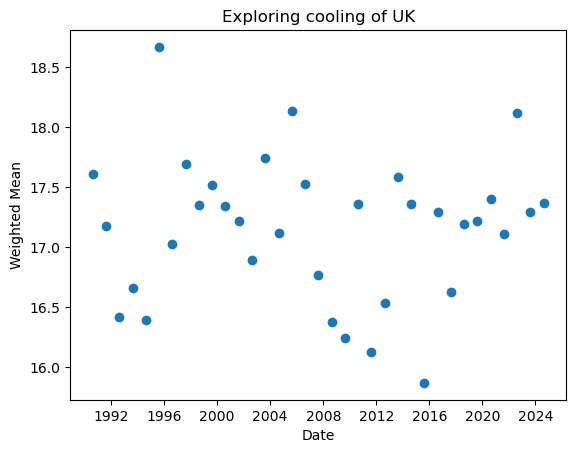

In [10]:
fig, ax = plt.subplots()
ax.scatter(august_means['time_counter'], august_means.values)
ax.set_xlabel('Date')
ax.set_ylabel('Weighted Mean')
ax.set_title('Exploring cooling of UK')


In [18]:
z = np.polyfit(august_means['time_counter'].dt.year, august_means.values, 1)
slope, intercept = z
line = slope * august_means['time_counter'].dt.year + intercept
print(slope)

-0.0021113105861871174


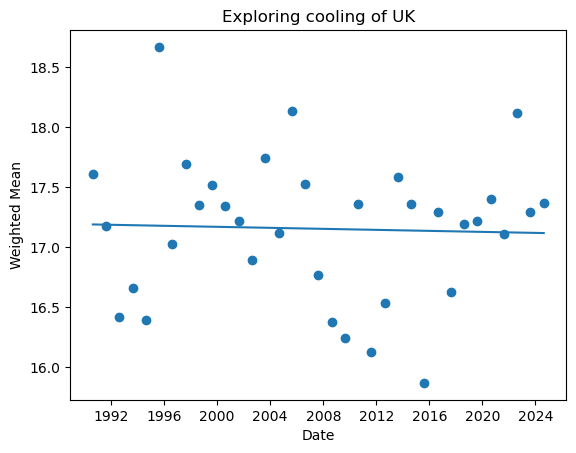

In [19]:
fig, ax = plt.subplots()
ax.scatter(august_means['time_counter'], august_means.values)
ax.plot(august_means['time_counter'], line)
ax.set_xlabel('Date')
ax.set_ylabel('Weighted Mean')
ax.set_title('Exploring cooling of UK')
plt.savefig('UK August cooling.png')

Text(0.5, 1.0, 'Cold Blob')

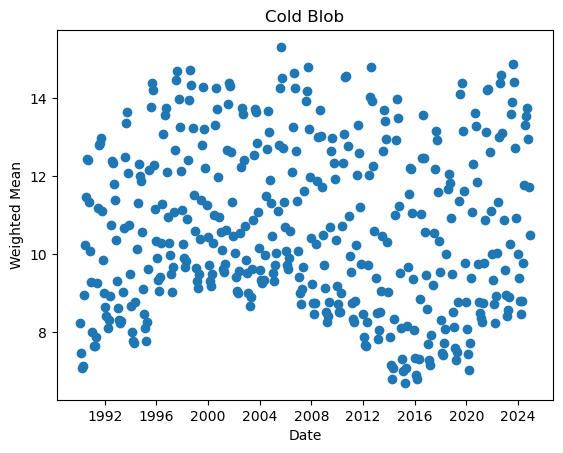

In [21]:
## Cold Blob - Area-weighted 

CB_weighted_mean = dt.masked_statistic(grid='/gridT', var='tos_con', lon_poly = [-35.0, -20.0, -20.0, -35.0, -35.0], lat_poly = [50.0, 50.0, 58.0, 58.0, 50], statistic="weighted_mean", dims=["i", "j"])
fig, ax = plt.subplots()
ax.scatter(CB_weighted_mean['time_counter'], CB_weighted_mean.values)
ax.set_xlabel('Date')
ax.set_ylabel('Weighted Mean')
ax.set_title('Cold Blob')


In [37]:
## Cold BLob - 30W, 55N

dt_indexed = dt.add_geoindex(grid="/gridT")
ds = (dt_indexed['/gridT']).dataset
CB = (ds['tos_con'].sel(gphit = 55.0, glamt = -30, method = 'nearest'))

In [38]:
CB

<xarray.DataArray 'tos_con' (time_counter: 420)> Size: 2kB
dask.array<getitem, shape=(420,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:00 ... ...
    time_centered  (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    j              int64 8B 943
    i              int64 8B 1030
    gphit          float64 8B dask.array<chunksize=(), meta=np.ndarray>
    glamt          float64 8B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

Text(0.5, 1.0, 'SST at 30W, 55N')

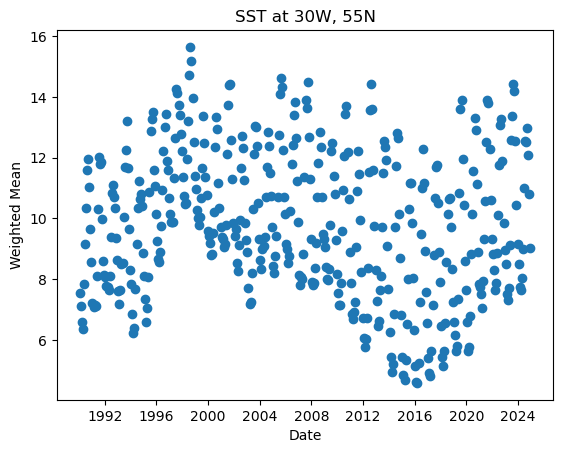

In [39]:
fig, ax = plt.subplots()
ax.scatter(CB['time_counter'], CB.values)
ax.set_xlabel('Date')
ax.set_ylabel('Weighted Mean')
ax.set_title('SST at 30W, 55N')